# 🤖 Part 2: 2DOF Forward Kinematics & Workspace

2자유도(2DOF) 로봇 팔의 **정기구학(Forward Kinematics, FK)** 및 **작업공간(Workspace)** 시각화 실습이다. 몬테카를로 샘플링 기법을 사용하여 로봇의 작동 범위를 그린다.

## 1. 2DOF FK 유도 및 비교

2자유도 로봇의 말단 좌표 $(x, y)$를 삼각함수와 DH 변환 행렬 두 방식으로 유도하고 비교한다.

### Method A: 기하학적 삼각함수 공식
$$
x = L_1\cos\theta_1 + L_2\cos(\theta_1 + \theta_2)
$$
$$
y = L_1\sin\theta_1 + L_2\sin(\theta_1 + \theta_2)
$$

### Method B: DH 변환 행렬 곱
$$
T_{02} = T_{01}(\theta_1) \cdot T_{12}(\theta_2) = \begin{bmatrix} R_{02} & \mathbf{p}_{end} \\ \mathbf{0}^T & 1 \end{bmatrix}
$$

In [1]:
import numpy as np

L1, L2 = 0.3, 0.3 # 링크 길이 (단위: m)

def fk_trig(theta1, theta2):
    """삼각함수 공식 기반 FK (입력: 라디안)"""
    x = L1 * np.cos(theta1) + L2 * np.cos(theta1 + theta2)
    y = L1 * np.sin(theta1) + L2 * np.sin(theta1 + theta2)
    return np.array([x, y])

def dh_matrix(a, d, alpha, theta):
    ct, st = np.cos(theta), np.sin(theta)
    ca, sa = np.cos(alpha), np.sin(alpha)
    return np.array([
        [ct, -st * ca,  st * sa, a * ct],
        [st,  ct * ca, -ct * sa, a * st],
        [ 0,       sa,       ca,      d],
        [ 0,        0,        0,      1]
    ])

def fk_dh(theta1, theta2):
    """DH 행렬 곱 기반 FK"""
    T_01 = dh_matrix(L1, 0, 0, theta1)
    T_12 = dh_matrix(L2, 0, 0, theta2)
    T_02 = T_01 @ T_12
    return T_02[0:2, 3] # x, y 좌표 추출

# 예제 1: 두 방식의 결괏값 비교 검증
t1, t2 = np.radians(45), np.radians(30)
pos_trig = fk_trig(t1, t2)
pos_dh = fk_dh(t1, t2)

print(f"삼각함수 결과: {pos_trig}")
print(f"DH 행렬 결과 : {pos_dh}")
print(f"오차: {np.linalg.norm(pos_trig - pos_dh):.2e} (두 결과가 완벽하게 일치함)")

삼각함수 결과: [0.28977775 0.50190978]
DH 행렬 결과 : [0.28977775 0.50190978]
오차: 1.24e-16 (두 결과가 완벽하게 일치함)


## 2. 관절 각에 따른 다중 포즈 시각화

다양한 관절 각도 조건에서 로봇 팔의 형상을 비교하여 확인한다.

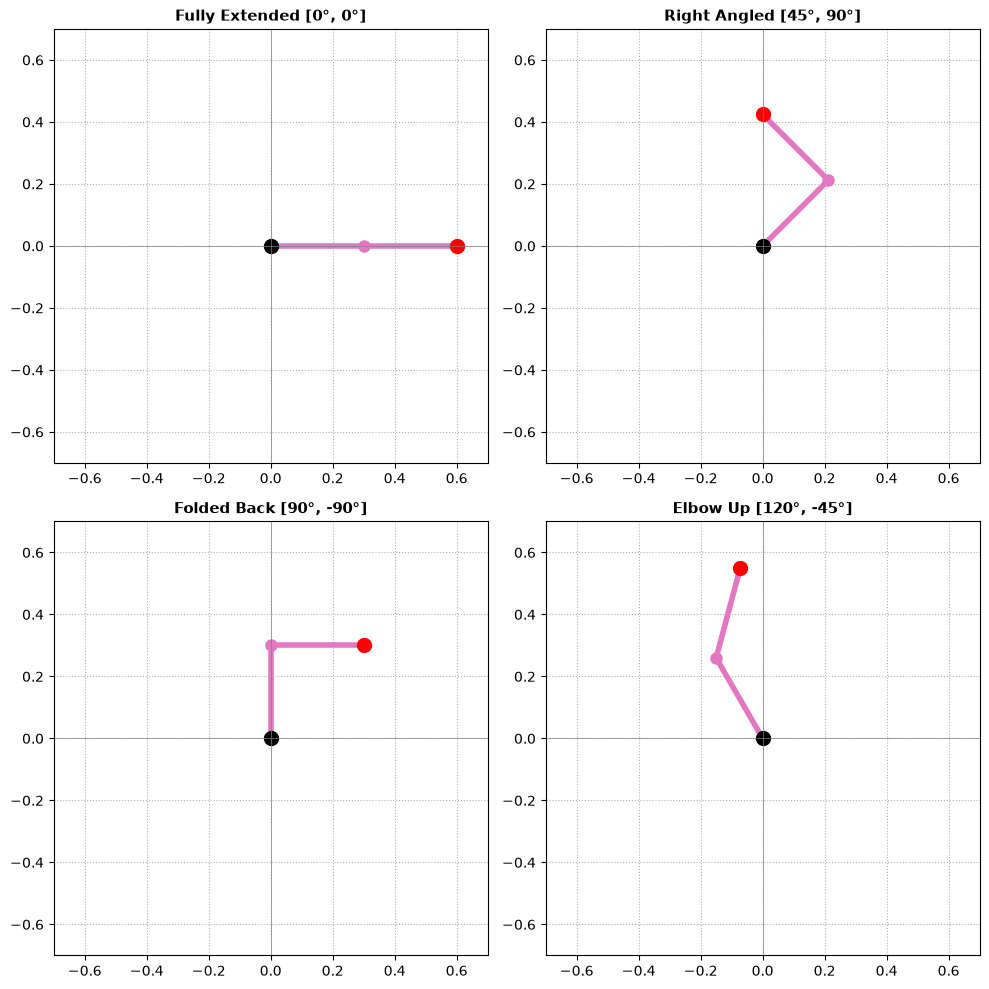

In [2]:
import matplotlib.pyplot as plt

def get_joint_positions(t1_deg, t2_deg):
    t1 = np.radians(t1_deg)
    t2 = np.radians(t2_deg)
    
    p0 = np.array([0.0, 0.0])
    p1 = np.array([L1 * np.cos(t1), L1 * np.sin(t1)])
    p2 = p1 + np.array([L2 * np.cos(t1 + t2), L2 * np.sin(t1 + t2)])
    return p0, p1, p2

# 예제 2: 4가지 대표 관절 포즈 시각화
poses = [
    (0, 0, "Fully Extended [0°, 0°]"),
    (45, 90, "Right Angled [45°, 90°]"),
    (90, -90, "Folded Back [90°, -90°]"),
    (120, -45, "Elbow Up [120°, -45°]")
]

fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs = axs.ravel()

for i, (t1, t2, title) in enumerate(poses):
    p0, p1, p2 = get_joint_positions(t1, t2)
    ax = axs[i]
    
    ax.plot([p0[0], p1[0], p2[0]], [p0[1], p1[1], p2[1]], 'o-', color='#e377c2', linewidth=4, markersize=8)
    ax.plot(p0[0], p0[1], 'ko', markersize=10)
    ax.plot(p2[0], p2[1], 'ro', markersize=10)
    
    ax.set_xlim(-0.7, 0.7)
    ax.set_ylim(-0.7, 0.7)
    ax.grid(True, linestyle=':')
    ax.axhline(0, color='grey', lw=0.5)
    ax.axvline(0, color='grey', lw=0.5)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

end effect의 절대 각도는 t1+t2이다. 두 번째 조인트를 새로운 원점으로 보았을 때 직관적이다.

## 3. 몬테카를로 기반 작업공간(Workspace) 시각화

각 관절의 각도 한계를 고려하여 로봇 말단이 도달할 수 있는 모든 영역을 시각화한다.

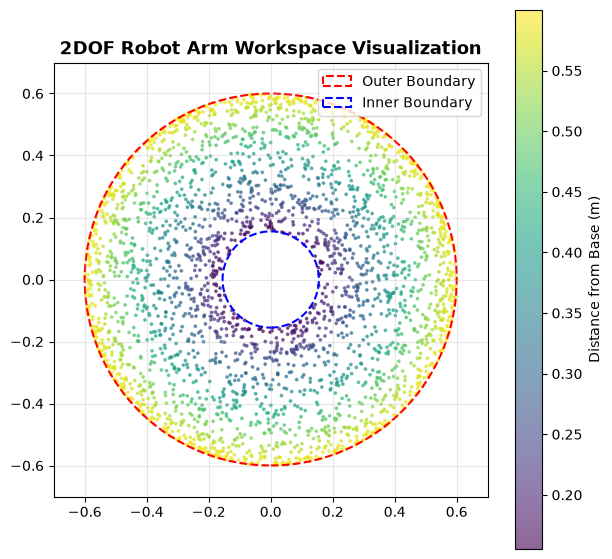

In [5]:
# 예제 3: 무작위 관절샘플링을 통한 도달가능 영역 매핑
num_samples = 3000
np.random.seed(42)

# 관절 각도 범위 설정 (단위: 도)
theta2_limit_deg = 150  # 관절 2의 제한 각도를 변수로 설정 (예: 150도)

# 관절 각도 랜덤 생성
theta1_samples = np.random.uniform(-np.pi, np.pi, num_samples)
theta2_samples = np.random.uniform(np.radians(-theta2_limit_deg), np.radians(theta2_limit_deg), num_samples)

x_dots = []
y_dots = []

for t1, t2 in zip(theta1_samples, theta2_samples):
    pos = fk_trig(t1, t2)
    x_dots.append(pos[0])
    y_dots.append(pos[1])
    
plt.figure(figsize=(7, 7))
plt.scatter(x_dots, y_dots, c=np.hypot(x_dots, y_dots), cmap='viridis', s=3, alpha=0.6)
plt.colorbar(label='Distance from Base (m)')

# 작업 영역 외부 경계원 그리기 (R = L1 + L2)
outer_circle = plt.Circle((0, 0), L1 + L2, color='red', fill=False, linestyle='--', linewidth=1.5, label='Outer Boundary')

# ★ 내부 한계선 그리기 (관절 각도 한계를 고려한 실제 최소 반경 계산)
r_inner = np.sqrt(L1**2 + L2**2 + 2 * L1 * L2 * np.cos(np.radians(theta2_limit_deg)))
inner_circle = plt.Circle((0, 0), r_inner, color='blue', fill=False, linestyle='--', linewidth=1.5, label='Inner Boundary')

plt.gca().add_patch(outer_circle)
plt.gca().add_patch(inner_circle)

plt.xlim(-0.7, 0.7)
plt.ylim(-0.7, 0.7)
plt.gca().set_aspect('equal')
plt.grid(True, alpha=0.3)
plt.title("2DOF Robot Arm Workspace Visualization", fontsize=13, fontweight='bold')
plt.legend()
plt.show()


현실적인 관절을 묘사하기 위해 두 번째 조인트를 최대 150도 까지 꺾을 수 있도록 제한.

아래와 같이 제한을 풀면 아래와 같이 로봇 팔이 도달할 수 있는 최대 거리인 $L_1+L_2$를 반지름으로 가지는 원 안의 어떤 곳이든 도달할 수 있음.

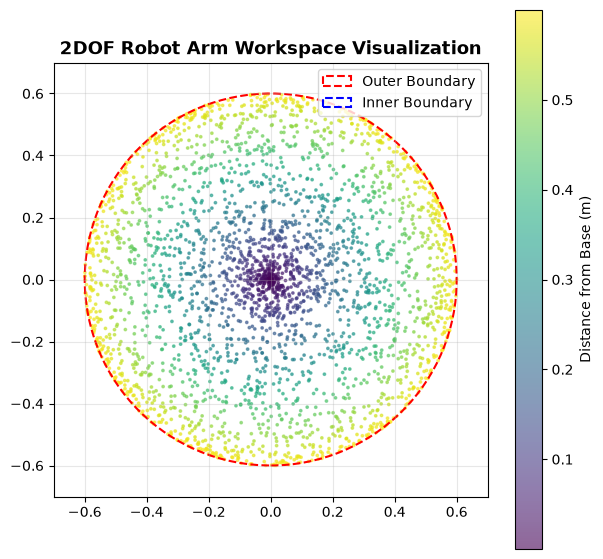

In [6]:
# 예제 3: 무작위 관절샘플링을 통한 도달가능 영역 매핑
num_samples = 3000
np.random.seed(42)

# 관절 각도 범위 설정 (단위: 도)
theta2_limit_deg = 180  # 관절 2의 제한 각도를 변수로 설정 (예: 150도)

# 관절 각도 랜덤 생성
theta1_samples = np.random.uniform(-np.pi, np.pi, num_samples)
theta2_samples = np.random.uniform(np.radians(-theta2_limit_deg), np.radians(theta2_limit_deg), num_samples)

x_dots = []
y_dots = []

for t1, t2 in zip(theta1_samples, theta2_samples):
    pos = fk_trig(t1, t2)
    x_dots.append(pos[0])
    y_dots.append(pos[1])
    
plt.figure(figsize=(7, 7))
plt.scatter(x_dots, y_dots, c=np.hypot(x_dots, y_dots), cmap='viridis', s=3, alpha=0.6)
plt.colorbar(label='Distance from Base (m)')

# 작업 영역 외부 경계원 그리기 (R = L1 + L2)
outer_circle = plt.Circle((0, 0), L1 + L2, color='red', fill=False, linestyle='--', linewidth=1.5, label='Outer Boundary')

# ★ 내부 한계선 그리기 (관절 각도 한계를 고려한 실제 최소 반경 계산)
r_inner = np.sqrt(L1**2 + L2**2 + 2 * L1 * L2 * np.cos(np.radians(theta2_limit_deg)))
inner_circle = plt.Circle((0, 0), r_inner, color='blue', fill=False, linestyle='--', linewidth=1.5, label='Inner Boundary')

plt.gca().add_patch(outer_circle)
plt.gca().add_patch(inner_circle)

plt.xlim(-0.7, 0.7)
plt.ylim(-0.7, 0.7)
plt.gca().set_aspect('equal')
plt.grid(True, alpha=0.3)
plt.title("2DOF Robot Arm Workspace Visualization", fontsize=13, fontweight='bold')
plt.legend()
plt.show()
